## Setup for EDA and time series 

In [75]:
# Importing required libraries
import requests
import pandas as pd
import csv
import numpy as np
from itertools import permutations

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

##
##
import glob
import json
import re
import os
##
##

 


### Columns
|Name                  | Description    |   uom         | Type     | format   |  | | | 

|---------------------|---------------------| ----------------| ----------------| ------------| --------------|----------|

| Stations_id|       | |    |VARCHAR2|     | |  | | 

| MESS_DATUM |       |reference data |    |CHAR |     | |  | | 

| QN_8 |       |quality level |    |numerical code |     | NUMBER|  |990| 

|  FF  |       | [\windspeed\,\missing value=- 999\]  |    |m/s |     | NUMBER|  |990| 

|  DD   |       |  [\winddirection\,\missing value=- 999\]  |    ° |     | NUMBER|  |990| 


In [76]:
# Get a list of all CSV files in a directory
# Sorted will append files in alphabetical order from 000 to last
txt_files = sorted(glob.glob('data/Kathrine_19.07.2023/excerpt/*.txt'), reverse=False)
# Create an empty list to store the data from each txt file
main_dataframe = []

count = 0
count_rows = 0
# Iterate over each txt file
for file in txt_files:
    # Read the txt file and store it in a DataFrame
    df = pd.read_table(file, encoding='latin1')#'ISO-8859-1')
    print(file, df.shape)
    # Append the DataFrame to the list
    main_dataframe.append(df)

    #count how many .txt files are appended
    count += 1
    count_rows += df.shape[0]

print(count)
print(count_rows) #to check if the headlines (row with column names) are added in each iteration of for loop
# Concatenate all the DataFrames into a single DataFrame
data_all_df = pd.concat(main_dataframe, ignore_index=False)
#data_all_df = pd.concat(main_dataframe, axis=1)

data/Kathrine_19.07.2023/excerpt/produkt_f_stunde_19490101_20221231_01975.txt (586635, 1)
data/Kathrine_19.07.2023/excerpt/produkt_f_stunde_19750701_20221231_01684.txt (393639, 1)
data/Kathrine_19.07.2023/excerpt/produkt_f_stunde_20220114_20230717_01684.txt (13200, 1)
data/Kathrine_19.07.2023/excerpt/produkt_f_stunde_20220114_20230717_01975.txt (13200, 1)
data/Kathrine_19.07.2023/excerpt/produkt_ff_stunde_19500101_20221231_01975.txt (639631, 1)
data/Kathrine_19.07.2023/excerpt/produkt_ff_stunde_19630101_20221231_01684.txt (523985, 1)
data/Kathrine_19.07.2023/excerpt/produkt_ff_stunde_20220114_20230717_01684.txt (13199, 1)
data/Kathrine_19.07.2023/excerpt/produkt_ff_stunde_20220114_20230717_01975.txt (12955, 1)
data/Kathrine_19.07.2023/excerpt/produkt_fx_stunde_19900602_20221231_01684.txt (196219, 1)
data/Kathrine_19.07.2023/excerpt/produkt_fx_stunde_19900701_20221231_01975.txt (195491, 1)
data/Kathrine_19.07.2023/excerpt/produkt_fx_stunde_20220114_20230717_01684.txt (13199, 1)
data/Kat

In [71]:
data_all_df.columns

Index(['STATIONS_ID;MESS_DATUM;QN_8;  FF;  DD;eor',
       'STATIONS_ID;MESS_DATUM;QN_3;   F;   D;eor',
       'STATIONS_ID;MESS_DATUM;QN_8;FX_911;eor',
       'STATIONS_ID;MESS_DATUM;QN_8;V_N_I; V_N;eor',
       'STATIONS_ID;MESS_DATUM;QN_7;SD_SO;eor',
       'STATIONS_ID;MESS_DATUM;QN_592;ATMO_LBERG;FD_LBERG;FG_LBERG;SD_LBERG;ZENIT;MESS_DATUM_WOZ;eor',
       'STATIONS_ID;MESS_DATUM;QN_8;V_VV_I;V_VV;eor',
       'STATIONS_ID;MESS_DATUM;QN_8;  WW;WW_Text;eor'],
      dtype='object')

In [72]:
data_all_df.head()

,STATIONS_ID;MESS_DATUM;QN_8; FF; DD;eor,STATIONS_ID;MESS_DATUM;QN_3; F; D;eor,STATIONS_ID;MESS_DATUM;QN_8;FX_911;eor,STATIONS_ID;MESS_DATUM;QN_8;V_N_I; V_N;eor,STATIONS_ID;MESS_DATUM;QN_7;SD_SO;eor,STATIONS_ID;MESS_DATUM;QN_592;ATMO_LBERG;FD_LBERG;FG_LBERG;SD_LBERG;ZENIT;MESS_DATUM_WOZ;eor,STATIONS_ID;MESS_DATUM;QN_8;V_VV_I;V_VV;eor,STATIONS_ID;MESS_DATUM;QN_8; WW;WW_Text;eor
0,1975;1949010100; 1; 10.3; 240;eor,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1975;1949010101; 1; 7.2; 240;eor,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1975;1949010102; 1; 7.2; 220;eor,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1975;1949010103; 1; 7.2; 220;eor,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1975;1949010104; 1; 6.2; 180;eor,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [74]:
data_all_df['STATIONS_ID;MESS_DATUM;QN_8;  WW;WW_Text;eor']

0                                                      NaN
1                                                      NaN
2                                                      NaN
3                                                      NaN
4                                                      NaN
                               ...                        
12954           1975;2023071620;    1;  -1;Wetter wurde...
12955           1975;2023071621;    1; 100;bei Bewölkun...
12956           1975;2023071622;    1;  -1;Wetter wurde...
12957           1975;2023071623;    1; 100;bei Bewölkun...
12958           1975;2023071700;    1; 100;bei Bewölkun...
Name: STATIONS_ID;MESS_DATUM;QN_8;  WW;WW_Text;eor, Length: 6871268, dtype: object

In [64]:
#This is another way of reading multiple text files and loading them into a data folder 
file_list = sorted(glob.glob('data/Kathrine_19.07.2023/excerpt/*.txt'), reverse=False)
main_dataframe = pd.DataFrame(pd.read_table(file_list[0]))
for i in range(1,len(file_list)):
    data = pd.read_table(file_list[i],encoding = 'latin1')
 #   data = pd.read_table(file_list[i],encoding = 'latin1', quotechar='"', engine='python', sep = ";")
    df = pd.DataFrame(data)
    main_dataframe = pd.concat([main_dataframe, df], ignore_index=False)
    #main_dataframe = pd.concat([main_dataframe, df], axis = 1)
  
print(main_dataframe)
# #creating a new csv file with# the dataframe we created
main_dataframe.to_csv('data/Weather_data.csv')

          STATIONS_ID;MESS_DATUM;QN_8;  FF;  DD;eor  \
0             1975;1949010100;    1;  10.3; 240;eor   
1             1975;1949010101;    1;   7.2; 240;eor   
2             1975;1949010102;    1;   7.2; 220;eor   
3             1975;1949010103;    1;   7.2; 220;eor   
4             1975;1949010104;    1;   6.2; 180;eor   
...                                             ...   
12954                                           NaN   
12955                                           NaN   
12956                                           NaN   
12957                                           NaN   
12958                                           NaN   

      STATIONS_ID;MESS_DATUM;QN_3;   F;   D;eor  \
0                                           NaN   
1                                           NaN   
2                                           NaN   
3                                           NaN   
4                                           NaN   
...                              

In [77]:
 df_Weather.columns

Index(['Unnamed: 0', 'STATIONS_ID;MESS_DATUM;QN_8;  FF;  DD;eor',
       'STATIONS_ID;MESS_DATUM;QN_3;   F;   D;eor',
       'STATIONS_ID;MESS_DATUM;QN_8;FX_911;eor',
       'STATIONS_ID;MESS_DATUM;QN_8;V_N_I; V_N;eor',
       'STATIONS_ID;MESS_DATUM;QN_7;SD_SO;eor',
       'STATIONS_ID;MESS_DATUM;QN_592;ATMO_LBERG;FD_LBERG;FG_LBERG;SD_LBERG;ZENIT;MESS_DATUM_WOZ;eor',
       'STATIONS_ID;MESS_DATUM;QN_8;V_VV_I;V_VV;eor',
       'STATIONS_ID;MESS_DATUM;QN_8;  WW;WW_Text;eor'],
      dtype='object')

In [65]:
# Import daataa
df_Weather = pd.read_csv('data/Weather_data.csv')
df_Weather.head(100)

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_87384/926413663.py:2: DtypeWarning: Columns (1,2,3,4,5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_Weather = pd.read_csv('data/Weather_data.csv')


,Unnamed: 0,STATIONS_ID;MESS_DATUM;QN_8; FF; DD;eor,STATIONS_ID;MESS_DATUM;QN_3; F; D;eor,STATIONS_ID;MESS_DATUM;QN_8;FX_911;eor,STATIONS_ID;MESS_DATUM;QN_8;V_N_I; V_N;eor,STATIONS_ID;MESS_DATUM;QN_7;SD_SO;eor,STATIONS_ID;MESS_DATUM;QN_592;ATMO_LBERG;FD_LBERG;FG_LBERG;SD_LBERG;ZENIT;MESS_DATUM_WOZ;eor,STATIONS_ID;MESS_DATUM;QN_8;V_VV_I;V_VV;eor,STATIONS_ID;MESS_DATUM;QN_8; WW;WW_Text;eor
0,0,1975;1949010100; 1; 10.3; 240;eor,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1975;1949010101; 1; 7.2; 240;eor,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1975;1949010102; 1; 7.2; 220;eor,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1975;1949010103; 1; 7.2; 220;eor,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1975;1949010104; 1; 6.2; 180;eor,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
95,95,1975;1949010423; 1; 3.1; 130;eor,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,96,1975;1949010500; 1; 3.1; 130;eor,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,97,1975;1949010501; 1; 2.6; 130;eor,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98,98,1975;1949010502; 1; 3.1; 130;eor,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### regional_averages_DE

In [78]:
#Tregional_averages_DE/Seasonal/sunshine_duration
file_list = sorted(glob.glob('data/Data_Bimla/regional_averages_DE/Seasonal/sunshine_duration/*.txt'), reverse=False)
main_dataframe_s = pd.DataFrame(pd.read_table(file_list[0]))
for i in range(1,len(file_list)):
    data = pd.read_table(file_list[i],encoding = 'latin1')
 #   data = pd.read_table(file_list[i],encoding = 'latin1', quotechar='"', engine='python', sep = ";")
    df = pd.DataFrame(data)
    main_dataframe_s = pd.concat([main_dataframe_s, df], ignore_index=False)
    #main_dataframe = pd.concat([main_dataframe, df], axis = 1)
  
print(main_dataframe_s)
# #creating a new csv file with# the dataframe we created
main_dataframe_s.to_csv('data/Regional_averages_DE_Seasonal_sunshine_duration_data.csv')

   Zeitreihen fuer Gebietsmittel fuer Bundeslaender und Kombinationen von Bundeslaender, erstellt am: 20221202  \
0   Jahr;autumn;Brandenburg/Berlin;Brandenburg;Bad...                                                            
1   1951;autumn;   465.3;   465.6;   377.0;   405....                                                            
2   1952;autumn;   223.4;   223.6;   254.9;   231....                                                            
3   1953;autumn;   397.0;   396.6;   399.9;   393....                                                            
4   1954;autumn;   322.8;   322.8;   357.5;   355....                                                            
..                                                ...                                                            
68                                                NaN                                                            
69                                                NaN                                   

In [79]:
# Import daataa
df_Seasonal_sunshine = pd.read_csv('data/Regional_averages_DE_Seasonal_sunshine_duration_data.csv')
df_Seasonal_sunshine.head(100)

,Unnamed: 0,"Zeitreihen fuer Gebietsmittel fuer Bundeslaender und Kombinationen von Bundeslaender, erstellt am: 20221202","Zeitreihen fuer Gebietsmittel fuer Bundeslaender und Kombinationen von Bundeslaender, erstellt am: 20230602","Zeitreihen fuer Gebietsmittel fuer Bundeslaender und Kombinationen von Bundeslaender, erstellt am: 20220914","Zeitreihen fuer Gebietsmittel fuer Bundeslaender und Kombinationen von Bundeslaender, erstellt am: 20230302"
0,0,Jahr;autumn;Brandenburg/Berlin;Brandenburg;Bad...,NaN,NaN,NaN
1,1,1951;autumn; 465.3; 465.6; 377.0; 405....,NaN,NaN,NaN
2,2,1952;autumn; 223.4; 223.6; 254.9; 231....,NaN,NaN,NaN
3,3,1953;autumn; 397.0; 396.6; 399.9; 393....,NaN,NaN,NaN
4,4,1954;autumn; 322.8; 322.8; 357.5; 355....,NaN,NaN,NaN
...,...,...,...,...,...
95,22,NaN,1972;spring; 431.9; 431.8; 413.6; 417....,NaN,NaN
96,23,NaN,1973;spring; 471.0; 470.9; 497.2; 491....,NaN,NaN
97,24,NaN,1974;spring; 573.5; 573.2; 489.9; 494....,NaN,NaN
98,25,NaN,1975;spring; 509.8; 509.3; 413.9; 437....,NaN,NaN


In [80]:
df_Seasonal_sunshine.columns

Index(['Unnamed: 0',
       'Zeitreihen fuer Gebietsmittel fuer Bundeslaender und Kombinationen von Bundeslaender, erstellt am: 20221202',
       'Zeitreihen fuer Gebietsmittel fuer Bundeslaender und Kombinationen von Bundeslaender, erstellt am: 20230602',
       'Zeitreihen fuer Gebietsmittel fuer Bundeslaender und Kombinationen von Bundeslaender, erstellt am: 20220914',
       'Zeitreihen fuer Gebietsmittel fuer Bundeslaender und Kombinationen von Bundeslaender, erstellt am: 20230302'],
      dtype='object')

### Current_Data 

In [44]:
# Import daataa
df_Current_Data = pd.read_csv('data/Kathrine_19.07.2023/Current_Data/Current_dwd_stations_ST_ST_solar_hourly_data.csv')
df_Current_Data.head(100)

,Stations_id,von_datum,bis_datum,Stationshoehe,geoBreite,geoLaenge,Stationsname,Bundesland
0,183,19810101,20230630,42,54.6791,13.4344,Arkona,Mecklenburg-Vorpommern
1,662,19580101,20230630,81,52.2915,10.4464,Braunschweig,Niedersachsen
2,853,19810101,20230630,416,50.7913,12.8720,Chemnitz,Sachsen
3,1048,19960901,20230630,228,51.1278,13.7543,Dresden-Klotzsche,Sachsen
4,1358,19580101,20230630,1213,50.4283,12.9536,Fichtelberg,Sachsen
5,1684,20010101,20230630,239,51.1621,14.9506,Görlitz,Sachsen
6,1975,20050101,20230630,11,53.6332,9.9881,Hamburg-Fuhlsbüttel,Hamburg
7,2290,19530101,20230630,977,47.8009,11.0108,Hohenpeißenberg,Bayern
8,2712,19770101,20230630,428,47.6952,9.1307,Konstanz,Baden-Württemberg
9,3015,19810101,20230630,98,52.2085,14.1180,Lindenberg,Brandenburg


In [98]:
df_Current_Data.shape

(23, 11)

In [83]:
df_Current_Data['von_datum'] = pd.to_datetime(df_Current_Data['von_datum'], format='%Y%m%d')
# Extract year, month and date from the datetime object
df_Current_Data['von_year'] = df_Current_Data['von_datum'].dt.year
#df_Current_Data['von_month'] = df_Current_Data['von_datum'].dt.month
#df_Current_Data['von_day'] =df_Current_Data['von_datum'].dt.day


df_Current_Data['bis_datum'] = pd.to_datetime(df_Current_Data['bis_datum'], format='%Y%m%d')
# Extract year, month and date from the datetime object
df_Current_Data['bis_year'] = df_Current_Data['bis_datum'].dt.year
#df_Current_Data['bis_month'] = df_Current_Data['bis_datum'].dt.month
#df_Current_Data['bis_day'] =df_Current_Data['bis_datum'].dt.day

df_Current_Data['diff_year']  = df_Current_Data['bis_year'] - df_Current_Data['von_year']
df_Current_Data.head()

,Stations_id,von_datum,bis_datum,Stationshoehe,geoBreite,geoLaenge,Stationsname,Bundesland,von_year,bis_year,diff_year
0,183,1981-01-01,2023-06-30,42,54.6791,13.4344,Arkona,Mecklenburg-Vorpommern,1981,2023,42
1,662,1958-01-01,2023-06-30,81,52.2915,10.4464,Braunschweig,Niedersachsen,1958,2023,65
2,853,1981-01-01,2023-06-30,416,50.7913,12.8720,Chemnitz,Sachsen,1981,2023,42
3,1048,1996-09-01,2023-06-30,228,51.1278,13.7543,Dresden-Klotzsche,Sachsen,1996,2023,27
4,1358,1958-01-01,2023-06-30,1213,50.4283,12.9536,Fichtelberg,Sachsen,1958,2023,65


In [96]:
#target_ycd = 'geoBreite'
target_ycd ='geoLaenge'


target_xcd = 'diff_year'
#target_xcd ='von_year'
#target_xcd =''bis_year'

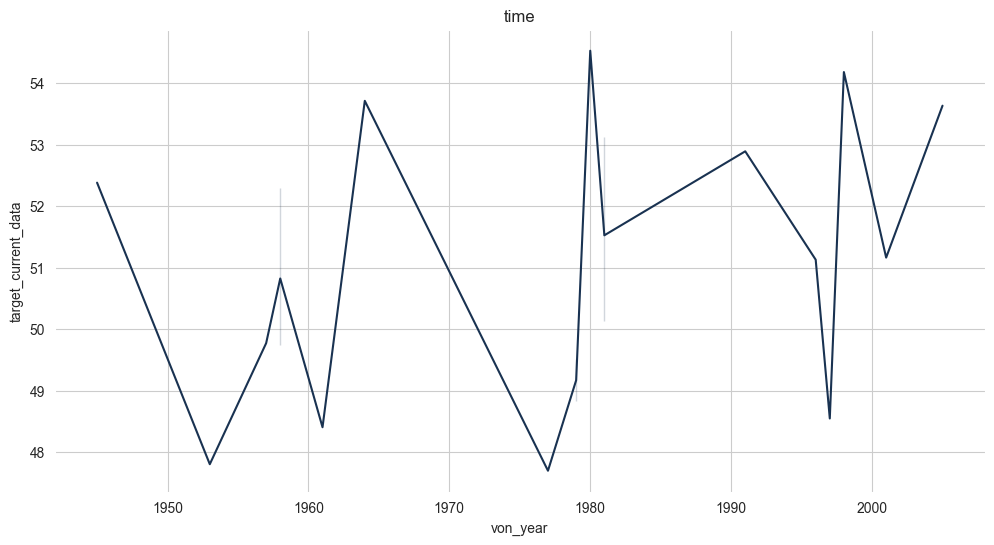

In [93]:
# Energy_mwh or Solar_mwh  development over year (time)
fig, ax = plt.subplots()
sns.lineplot(x = target_xcd, y= target_ycd, data=df_Current_Data, ax=ax)
ax.set(title='time', ylabel='target_current_data');
#fig.savefig("visualisations/.png",dpi=300)

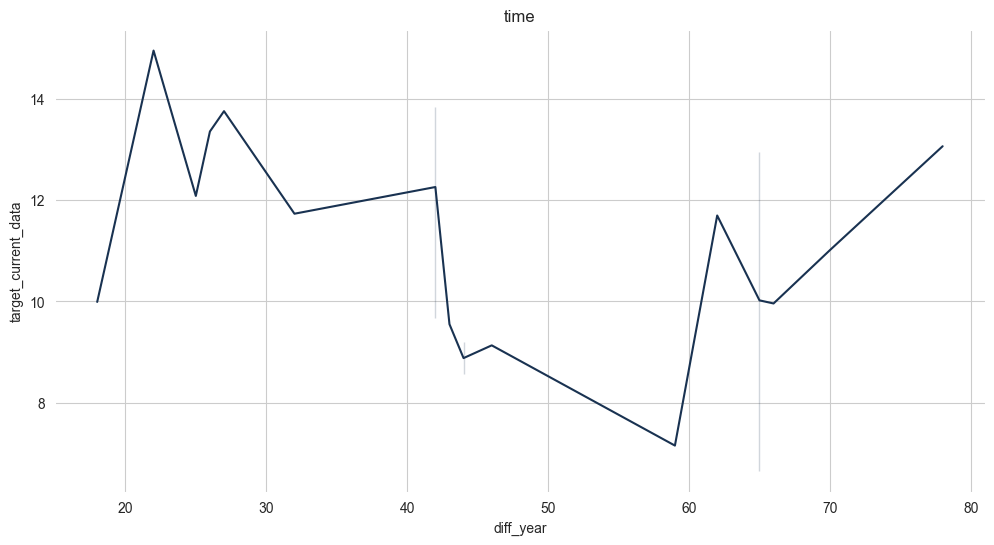

In [97]:
# Energy_mwh or Solar_mwh  development over year (time)
fig, ax = plt.subplots()
sns.lineplot(x = target_xcd, y= target_ycd, data=df_Current_Data, ax=ax)
ax.set(title='time', ylabel='target_current_data');
#fig.savefig("visualisations/.png",dpi=300)